## EDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('predictive_maintenance.csv')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB
None


In [ ]:
print(df.head())
print(df.columns)
print(len(df.columns))

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  
Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 

In [ ]:
print(df['Type'].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [ ]:
print(df['Failure Type'].value_counts())

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


In [ ]:
print(df['Target'].value_counts())

Target
0    9661
1     339
Name: count, dtype: int64


Label Encoding

In [ ]:
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])
df['Failure Type'] = le.fit_transform(df['Failure Type'])

Feature and Target Split

In [ ]:
X = df.drop(['Target', 'Product ID', 'UDI'], axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       0.99      0.97      0.98        68

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



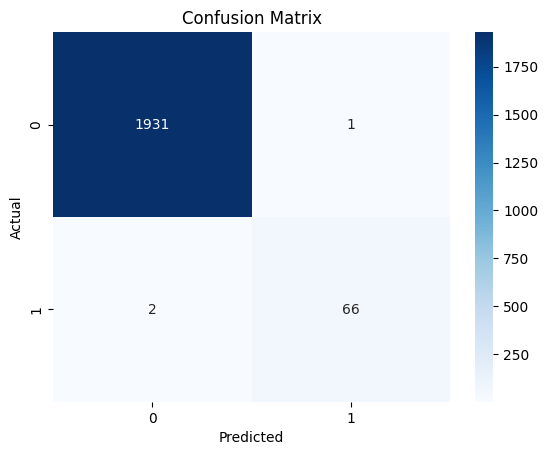

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

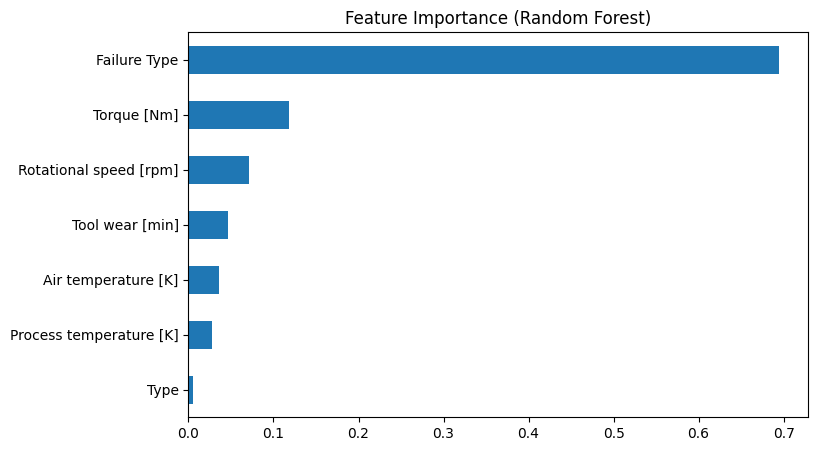

In [ ]:
feat_importance = pd.Series(rf.feature_importances_, index=df.drop(['Target', 'Product ID', 'UDI'], axis=1).columns)
feat_importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title('Feature Importance (Random Forest)')
plt.show()

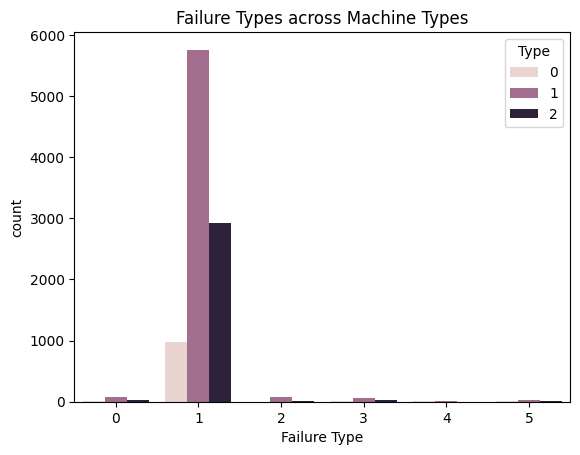

In [ ]:
sns.countplot(x='Failure Type', data=df, hue='Type')
plt.title('Failure Types across Machine Types')
plt.show()

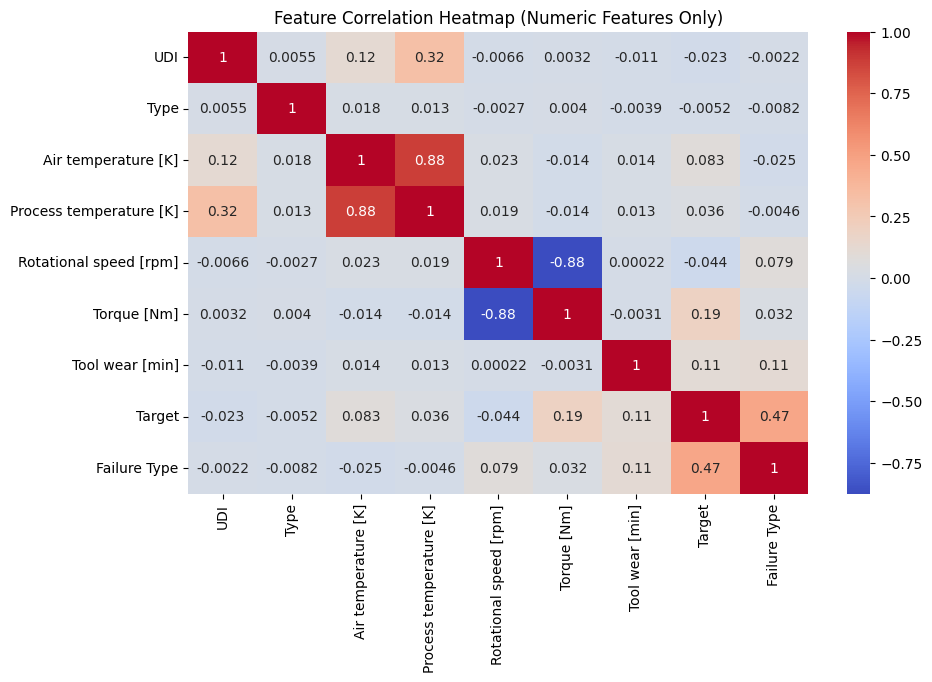

In [ ]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap (Numeric Features Only)')
plt.show()

## Initial Model

In [2]:
pip install numpy pandas matplotlib seaborn scikit-learn -q

In [3]:
!pip install xgboost==1.7.6 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 4.7 MB/s eta 0:00:00


In [4]:
import xgboost as xgb
print(xgb.__version__)

1.7.6


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nasa-cmaps' dataset.
Path to dataset files: /kaggle/input/nasa-cmaps


In [8]:
!ls -R /kaggle/input/nasa-cmaps

/kaggle/input/nasa-cmaps:
CMaps

/kaggle/input/nasa-cmaps/CMaps:
'Damage Propagation Modeling.pdf'   RUL_FD004.txt    train_FD001.txt
 readme.txt			    test_FD001.txt   train_FD002.txt
 RUL_FD001.txt			    test_FD002.txt   train_FD003.txt
 RUL_FD002.txt			    test_FD003.txt   train_FD004.txt
 RUL_FD003.txt			    test_FD004.txt   x.txt


In [7]:
!python main.py /root/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/train_FD001.txt

/content/main.py:88: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(found, sep='\s+', header=None, names=cols)

Starting improved predictive maintenance pipeline
Loading data from: /root/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/train_FD001.txt
Removed 6 sensors/settings: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_19', 'op_setting_3']
Computed RUL for each row (no piecewise cap applied)
Created 17631 windows of size 30. Features per step: 51
Train samples: 14161, Test samples: 3470
Train engines: 80, Test engines: 20
Using XGBoost XGBRegressor

Main model evaluation:
RMSE: 3.150
MAE:  1.780
R2:   0.997

Training quantile regressors for uncertainty estimation (may take time)...
Quantile coverage (5-95): 81.96%
Mean predicted uncertainty (approx std): 12.744

Cost-aware analysis:
   threshold    avg_cost   tp  fp  fn
0          5   29.682997  100   6   0
1         10   63.544669  198   5   2
2         15   92.651297  298   7   2
3     

# Final Model

In [2]:
pip install numpy pandas matplotlib seaborn scikit-learn -q

In [3]:
!pip install xgboost==1.7.6 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 5.6 MB/s eta 0:00:00


In [4]:
import xgboost as xgb
print(xgb.__version__)

1.7.6


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Path to dataset files:", path)

100%|██████████| 12.3M/12.3M [00:01<00:00, 7.81MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1


In [17]:
!python main.py all


Training FD001

Using dataset FD001 from: /root/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps
Rolling Features: 100% 16/16 [00:00<00:00, 33.95it/s]
Windowing Engines: 100% 100/100 [00:00<00:00, 518.85it/s]
Using GPU XGBoost

Training model...

FD001 Results → RMSE=21.378, MAE=16.063, R2=0.880
Saved models for FD001

Saved: plots/FD001_actual_vs_pred.png
Saved: plots/FD001_error_distribution.png

Training FD002

Using dataset FD002 from: /root/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps
Rolling Features: 100% 16/16 [00:01<00:00, 10.20it/s]
Windowing Engines: 100% 260/260 [00:00<00:00, 351.41it/s]
Using GPU XGBoost

Training model...

FD002 Results → RMSE=27.595, MAE=20.396, R2=0.811
Saved models for FD002

Saved: plots/FD002_actual_vs_pred.png
Saved: plots/FD002_error_distribution.png

Training FD003

Using dataset FD003 from: /root/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps
Rolling Features: 100% 16/16 [00:00<00:00, 37.97it/s]
Wi